# Projet — Exploitation du dateset CL-Drive

## Estimation de la charge cognitive du conducteur

Ce TP vient après les TD1, TD2, TD3 et TD4.

Les TD ont déjà permis de travailler :

- la compréhension du papier CL-Drive ;
- le protocole expérimental ;
- la segmentation en fenêtres de 10 s ;
- le prétraitement EEG ;
- l'extraction des features EEG.

Le point de départ du TP est donc le dossier généré à la fin du TD4 :

```text
EEG_Features_10s/
```

Ce TP ne revient pas sur le calcul des features. Il exploite les features déjà extraites pour construire un pipeline d'apprentissage automatique.

## Objectif du TP

Construire un pipeline complet :

```text
EEG_Features_10s
→ Normalized_Features_10s/EEG
→ Normalized_Features_10s_With_Label/EEG
→ Dataset EEG supervisé
→ Classification de la charge cognitive
→ Évaluation
→ Interprétation
```

Dans un premier temps, on se limite à l'EEG uniquement.

La multimodalité, c'est-à-dire l'ajout de ECG, EDA et Gaze, sera proposée uniquement comme extension à la fin du sujet.

In [ ]:
!unzip -o /content/Data.zip -d /content/Data

Archive:  /content/Data.zip
  inflating: /content/Data/EEG_Features_10s/1868_features.csv  
  inflating: /content/Data/EEG_Features_10s/1323_features.csv  
  inflating: /content/Data/EEG_Features_10s/1544_features.csv  
  inflating: /content/Data/EEG_Features_10s/1434_features.csv  
  inflating: /content/Data/EEG_Features_10s/1892_features.csv  
  inflating: /content/Data/EEG_Features_10s/1271_features.csv  
  inflating: /content/Data/EEG_Features_10s/1716_features.csv  
  inflating: /content/Data/EEG_Features_10s/1547_features.csv  
  inflating: /content/Data/EEG_Features_10s/1953_features.csv  
  inflating: /content/Data/EEG_Features_10s/1744_features.csv  
  inflating: /content/Data/EEG_Features_10s/1717_features.csv  
  inflating: /content/Data/EEG_Features_10s/1314_features.csv  
  inflating: /content/Data/EEG_Features_10s/1417_features.csv  
  inflating: /content/Data/EEG_Features_10s/1629_features.csv  
  inflating: /content/Data/EEG_Features_10s/1595_features.csv  
  inflating:

## 1. Structure attendue des dossiers

Avant de commencer, le dossier de travail doit contenir au minimum :

```text
Data/
├── EEG/ID_x
│   ├── ... fichiers level_1, level_2, ..., level_9
│   ├── ... fichiers baseline
│   └──processed_eeg/
|      ├── ... fichiers filtered_*
│
├── EEG_Features_10s/
│   ├── ID1_EEG_features.csv
│   ├── ID2_EEG_features.csv
│   └── ...
│
├── Labels/
│   ├── ID1.csv
│   ├── ID2.csv
│   └── ...
```

Le TP va générer deux nouveaux dossiers :

```text
Data/
├── Normalized_Features_10s/
│   └── EEG/
│       ├── norm_ID1_EEG_features.csv
│       ├── norm_ID2_EEG_features.csv
│       └── ...
│
├── Normalized_Features_10s_With_Label/(avec colonnes Level et Label)
│   └── EEG/
│       ├── norm_ID1_EEG_features.csv
│       ├── norm_ID2_EEG_features.csv
│       └── ...
```

## Question

Pourquoi ne faut-il pas entraîner directement les modèles sur les fichiers `EEG_Features_10s`  ?

### Réponse
Les fichiers EEG_Features_10s contiennent des features brutes, non normalisées et sans label de charge cognitive. Entraîner directement un modèle sur ces données poserait plusieurs problèmes :

Échelles hétérogènes : les features EEG (puissances spectrales, ratios de bandes) n'ont pas les mêmes ordres de grandeur. Un modèle sensible aux distances (KNN, SVM) serait biaisé vers les features à grande variance.
Variabilité inter-individuelle : chaque sujet a une activité EEG de base différente. Sans normalisation par baseline, le modèle apprend des différences entre individus plutôt que des variations liées à la charge cognitive.
Absence de cible : les fichiers ne contiennent pas encore les scores PAAS. Il est donc impossible d'entraîner un modèle supervisé sans l'étape d'ajout des labels.
...

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

BASE_PATH = Path("/content/Data")

EEG_FEATURE_DIR = BASE_PATH / "EEG_Features_10s"
LABEL_DIR = BASE_PATH / "Labels"
NORMALIZED_EEG_DIR = BASE_PATH / "Normalized_Features_10s" / "EEG"
LABELED_EEG_DIR = BASE_PATH / "Normalized_Features_10s_With_Label" / "EEG"

NORMALIZED_EEG_DIR.mkdir(parents=True, exist_ok=True)
LABELED_EEG_DIR.mkdir(parents=True, exist_ok=True)

METADATA_COLUMNS = ["Participant", "File", "Window", "Start_Time", "End_Time", "Channel"]

## 2. Normalisation des features EEG

À la fin du TD4, chaque fichier CSV contient des features EEG calculées sur des fenêtres de 10 secondes.

La normalisation doit suivre deux étapes :

### Étape 1 — Normalisation par la baseline du sujet

Pour chaque sujet, les fichiers de baseline servent à calculer une valeur moyenne de référence pour chaque feature :

$$
\mu_{baseline}^{(s,f)} = \frac{1}{N}\sum_{i=1}^{N} x_i^{(s,f)}
$$

où :

- $s$ désigne le sujet ;
- $f$ désigne la feature ;
- $x_i^{(s,f)}$ désigne la valeur de la feature pendant la baseline.

Chaque valeur de feature dans les fichiers de tâche est ensuite divisée par la moyenne de baseline correspondante :

$$
x_{norm}^{(s,f)} = \frac{ x^{(s,f)} }{ \mu_{baseline}^{(s,f)} }
$$

### Étape 2 — Standardisation z-score

On applique ensuite une standardisation :

$$
z = \frac{x - \mu}{\sigma}
$$

Cela permet d’obtenir des features centrées et réduites. Cette étape devra toutefois être réalisée plus loin dans le pipeline, après la séparation des données entre les ensembles d’entraînement et de test (voir section 8 ci-dessous).

## Question

Quel est l'intérêt de la normalisation par baseline dans des signaux physiologiques ?

### Réponse
Dans les signaux physiologiques, chaque individu a un niveau d'activité de référence qui lui est propre (on parle de variabilité inter-individuelle). Par exemple, la puissance delta d'un sujet au repos peut être deux fois plus élevée que celle d'un autre, sans que cela reflète une différence de charge cognitive.
La normalisation par baseline consiste à diviser chaque valeur de feature par la moyenne de ce même sujet au repos. Cela permet de raisonner en termes de variation relative par rapport à la ligne de base, indépendamment du niveau absolu de chaque individu.

Dans notre dataset, cette normalisation est d'autant plus importante que certains sujets n'ont pas de baseline disponible (ex. sujets 1337, 1323, 1744…), ce qui a généré des avertissements lors de l'exécution. Ces sujets conservent leurs valeurs brutes, ce qui peut légèrement biaiser leur contribution au dataset final.
...

In [ ]:


def get_feature_columns(df, metadata_columns=METADATA_COLUMNS):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [col for col in numeric_cols if col not in metadata_columns]


def compute_baseline_averages(feature_dir):
    baseline_avgs = {}

    for file_path in Path(feature_dir).glob("*.csv"):

        if "baseline" not in file_path.name.lower():
            continue

        df = pd.read_csv(file_path)

        participant = str(df["Participant"].iloc[0])
        feature_cols = get_feature_columns(df)

        baseline_avgs[participant] = df[feature_cols].mean()

    return baseline_avgs


def normalize_by_baseline(df, participant_id, baseline_avgs):

    df_norm = df.copy()

    feature_cols = get_feature_columns(df_norm)

    if participant_id not in baseline_avgs:
        print("Baseline manquante pour :", participant_id)
        return df_norm

    baseline_mean = baseline_avgs[participant_id]

    for col in feature_cols:
        if col in baseline_mean.index:
            if baseline_mean[col] != 0:
                df_norm[col] = df_norm[col] / baseline_mean[col]

    return df_norm


def run_eeg_normalization():

    baseline_avgs = compute_baseline_averages(EEG_FEATURE_DIR)

    for file_path in EEG_FEATURE_DIR.glob("*.csv"):

        if "baseline" in file_path.name.lower():
            continue

        df = pd.read_csv(file_path)

        participant = str(df["Participant"].iloc[0])

        df_norm = normalize_by_baseline(df, participant, baseline_avgs)

        output_file = NORMALIZED_EEG_DIR / f"norm_{file_path.name}"

        df_norm.to_csv(output_file, index=False)

        print("Sauvegardé :", output_file)

In [ ]:
run_eeg_normalization()

Baseline manquante pour : 1547
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1547_features.csv
Baseline manquante pour : 1106
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1106_features.csv
Baseline manquante pour : 1417
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1417_features.csv
Baseline manquante pour : 1372
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1372_features.csv
Baseline manquante pour : 1544
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1544_features.csv
Baseline manquante pour : 1629
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1629_features.csv
Baseline manquante pour : 1868
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1868_features.csv
Baseline manquante pour : 1716
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1716_features.csv
Baseline manquante pour : 1241
Sauvegardé : /content/Data/Normalized_Features_10s/EEG/norm_1241_features.csv
Baseline manquante 

## 3. Vérification du dossier `Normalized_Features_10s/EEG`

Après exécution de la normalisation, vérifiez que le dossier contient bien des fichiers `norm_*.csv`.

## Question

Pourquoi les fichiers de baseline ne sont-ils pas copiés dans le dossier normalisé final ?

### Réponse
Les fichiers de baseline ont un rôle de référence de calcul, pas de donnée d'entraînement. Ils servent uniquement à estimer la moyenne de repos de chaque sujet pour normaliser les features des tâches.
Les inclure dans Normalized_Features_10s/EEG poserait deux problèmes :

Contamination du dataset : les segments de baseline ne correspondent à aucun niveau de charge cognitive précis, ils ne peuvent pas être labellisés avec un score PAAS valide.

Fuite d'information (data leakage) : si le modèle voit des données de baseline pendant l'entraînement, il pourrait apprendre des caractéristiques du repos plutôt que de la charge, biaisant l'évaluation.
...

In [ ]:


print("Fichiers normalisés :")
for f in NORMALIZED_EEG_DIR.glob("*.csv"):
    print(f.name)


Fichiers normalisés :
norm_1271_features.csv
norm_1372_features.csv
norm_1241_features.csv
norm_1544_features.csv
norm_1105_features.csv
norm_1323_features.csv
norm_1314_features.csv
norm_1744_features.csv
norm_1868_features.csv
norm_1434_features.csv
norm_1030_features.csv
norm_1892_features.csv
norm_1106_features.csv
norm_1595_features.csv
norm_1953_features.csv
norm_1337_features.csv
norm_1717_features.csv
norm_1417_features.csv
norm_1547_features.csv
norm_1629_features.csv
norm_1716_features.csv


## 4. Ajout des colonnes `Level` et `Label`

Les fichiers normalisés ne contiennent pas encore la cible d'apprentissage.

Il faut maintenant associer chaque fenêtre de 10 secondes à son score PAAS.

Les labels sont stockés dans le dossier :

```text
Labels/
```

Chaque fichier de labels correspond à un sujet, par exemple :

```text
Labels/ID1.csv
Labels/ID2.csv
...
```

Dans ces fichiers, on suppose une structure du type :

| time | lvl_1 | lvl_2 | ... | lvl_9 |
|---:|---:|---:|---|---:|
| 10 | 2 | 3 | ... | 5 |
| 20 | 2 | 4 | ... | 6 |
| ... | ... | ... | ... | ... |

Pour une fenêtre d'indice `Window`, le temps associé est :

$$
time = (Window + 1) \times 10
$$

Le niveau du scénario est extrait du nom du fichier avec une expression régulière :

```text
level_1 → Level = 1
level_2 → Level = 2
...
level_9 → Level = 9
```

Le score PAAS est ensuite récupéré dans la colonne :

```text
lvl_<Level>
```

Exemple : si `Level = 4`, on lit la colonne `lvl_4`.


In [ ]:


def extract_level_from_filename(file_name):

    match = re.search(r"level[_\- ]?(\d+)", file_name.lower())

    if match:
        return int(match.group(1))

    return None


def get_label_for_row(row, labels_df):

    window = int(row["Window"])
    level = int(row["Level"])

    time_stamp = (window + 1) * 10
    label_col = f"lvl_{level}"

    if label_col not in labels_df.columns:
        return np.nan

    match = labels_df[labels_df["time"] == time_stamp]

    if len(match) == 0:
        return np.nan

    return match[label_col].iloc[0]


def attach_labels_eeg():

    for file_path in NORMALIZED_EEG_DIR.glob("*.csv"):

        df = pd.read_csv(file_path)

        participant = str(df["Participant"].iloc[0])

        label_file = LABEL_DIR / f"{participant}.csv"

        if not label_file.exists():
            print("Label introuvable :", label_file)
            continue

        labels_df = pd.read_csv(label_file)

        level = extract_level_from_filename(str(df["File"].iloc[0]))

        if level is None:
            print("Level introuvable :", label_file.name)
            continue

        df["Level"] = level

        df["Label"] = df.apply(
            lambda row: get_label_for_row(row, labels_df),
            axis=1
        )

        df = df.dropna(subset=["Label"])

        output_file = LABELED_EEG_DIR / file_path.name

        df.to_csv(output_file, index=False)

        print("Sauvegardé :", output_file)

In [ ]:
attach_labels_eeg()

Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1271_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1372_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1241_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1544_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1105_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1323_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1314_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1744_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1868_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1434_features.csv
Sauvegardé : /content/Data/Normalized_Features_10s_With_Label/EEG/norm_1030_features.csv
Sauvegardé : /content

## 5. Vérification du dossier `Normalized_Features_10s_With_Label/EEG`

Le dossier final doit contenir des fichiers CSV avec au moins :

- les métadonnées : `Participant`, `File`, `Window`, `Channel`, `Start_Time` et `End_Time` ;
- les features EEG normalisées ;
- la colonne `Level` ;
- la colonne `Label`.

## Question

Quelle est la différence entre `Level` et `Label` dans ce TP ? Pourquoi faut-il ajouter à la fois `Level` et `Label` ?

### Réponse
Level correspond au numéro du scénario de conduite (de 1 à 9), extrait du nom du fichier (ex. level_4). C'est une variable de contexte qui identifie quelle condition expérimentale était en cours.
Label correspond au score PAAS (Primary Task NASA-TLX Assessment Scale) renseigné par le participant pour ce niveau, lu dans les fichiers Labels/. C'est la cible d'apprentissage pour la classification.

Il faut conserver Level car il est nécessaire pour retrouver la bonne colonne lvl_<Level> dans les fichiers de labels. Une fois le label associé, Level reste utile pour des analyses exploratoires (distribution des labels par niveau de difficulté). Le Label est ce que l'on cherche à prédire : la charge cognitive subjective du conducteur à un instant donné.
...

In [ ]:


for f in LABELED_EEG_DIR.glob("*.csv"):
    df_test = pd.read_csv(f)
    print(f.name, df_test.shape, df_test.columns.tolist())


norm_1271_features.csv (572, 48) ['delta_absolute_power', 'delta_mean_power', 'delta_max_power', 'delta_min_power', 'delta_median_power', 'theta_absolute_power', 'theta_mean_power', 'theta_max_power', 'theta_min_power', 'theta_median_power', 'alpha_absolute_power', 'alpha_mean_power', 'alpha_max_power', 'alpha_min_power', 'alpha_median_power', 'beta_absolute_power', 'beta_mean_power', 'beta_max_power', 'beta_min_power', 'beta_median_power', 'gamma_absolute_power', 'gamma_mean_power', 'gamma_max_power', 'gamma_min_power', 'gamma_median_power', 'delta_spectral_entropy', 'theta_spectral_entropy', 'alpha_spectral_entropy', 'beta_spectral_entropy', 'gamma_spectral_entropy', 'hjorth_mobility', 'hjorth_complexity', 'lempel_ziv_complexity', 'higuchi_fd', 'raw_mean', 'raw_min', 'raw_max', 'raw_median', 'raw_variance', 'raw_std', 'Participant', 'File', 'Window', 'Channel', 'Start_Time', 'End_Time', 'Level', 'Label']
norm_1372_features.csv (648, 48) ['delta_absolute_power', 'delta_mean_power', 'd

## 6. Construction du dataset EEG supervisé

Une fois les fichiers normalisés et labellisés générés, on peut les concaténer pour construire un tableau unique.

Chaque ligne représente une fenêtre EEG de 10 secondes pour un canal.

On construit ensuite deux problèmes possibles :

### Classification binaire

| Score PAAS | Classe |
|---:|---|
| 1 à 4 | faible |
| 5 à 9 | élevée |

### Classification ternaire, extension

| Score PAAS | Classe |
|---:|---|
| 1 à 3 | faible |
| 4 à 6 | moyenne |
| 7 à 9 | élevée |

Dans ce TP, l'objectif principal est la classification binaire.

In [ ]:


def load_labeled_eeg_dataset():

    all_files = []

    for file_path in LABELED_EEG_DIR.glob("*.csv"):
        df = pd.read_csv(file_path)
        all_files.append(df)

    if len(all_files) == 0:
        raise ValueError("Aucun fichier labellisé trouvé.")

    return pd.concat(all_files, ignore_index=True)


df = load_labeled_eeg_dataset()

print(df.shape)
df.head()

(12552, 48)


,delta_absolute_power,delta_mean_power,delta_max_power,delta_min_power,delta_median_power,theta_absolute_power,theta_mean_power,theta_max_power,theta_min_power,theta_median_power,...,raw_variance,raw_std,Participant,File,Window,Channel,Start_Time,End_Time,Level,Label
0,2192.985014,313.283573,565.275351,128.267368,273.580439,485.589242,60.698655,107.715683,28.321501,55.238435,...,1245.927848,35.297703,1271,eeg_data_level_1.csv,0,AF7,120.007812,130.003906,1,3.0
1,1929.012887,275.573270,452.485279,120.233240,256.061828,454.151229,56.768904,80.763042,33.130166,52.980427,...,1093.195897,33.063513,1271,eeg_data_level_1.csv,0,AF8,120.007812,130.003906,1,3.0
2,5998.331000,856.904429,1331.376351,613.927367,675.925535,1722.764647,215.345581,663.332419,53.943018,156.126846,...,4216.303612,64.933070,1271,eeg_data_level_1.csv,0,TP9,120.007812,130.003906,1,3.0
3,3877.983276,553.997611,772.444917,435.681039,554.205791,1205.042289,150.630286,404.748456,65.125425,131.714028,...,3118.294052,55.841687,1271,eeg_data_level_1.csv,0,TP10,120.007812,130.003906,1,3.0
4,1020.907387,145.843912,242.968101,36.095561,164.953658,285.146345,35.643293,75.088035,4.643824,33.147931,...,657.191782,25.635752,1271,eeg_data_level_1.csv,1,AF7,130.007812,140.003906,1,3.0


In [ ]:


df["Label_Binary"] = df["Label"].apply(
    lambda x: 0 if x <= 4 else 1
)

df["Label_Ternary"] = df["Label"].apply(
    lambda x: 0 if x <= 3 else (1 if x <= 6 else 2)
)

df[["Label", "Label_Binary", "Label_Ternary"]].head()

,Label,Label_Binary,Label_Ternary
0,3.0,0,0
1,3.0,0,0
2,3.0,0,0
3,3.0,0,0
4,3.0,0,0


## 7. Préparation de la matrice d'apprentissage

On doit séparer :

- les métadonnées ;
- les features numériques EEG ;
- la cible d'apprentissage.

## Question

Pourquoi ne faut-il pas inclure `Participant`, `File`, `Window`, `Level` ou `Label` dans les features du modèle ?

### Réponse
Label : c'est la cible y — l'inclure dans X serait une fuite d'information directe.

Participant, File, Window : ce sont des métadonnées sans lien causal avec l'état cognitif. Le modèle apprendrait l'identité du sujet ou la structure des fichiers plutôt que le signal EEG.

Level : corrélé à la difficulté, mais inconnu en conditions réelles — l'inclure empêcherait toute généralisation à de nouvelles situations.

...

In [ ]:


cols_to_remove = [
    "Participant", "File", "Window",
    "Start_Time", "End_Time", "Channel",
    "Level", "Label", "Label_Binary", "Label_Ternary"
]

feature_cols = [
    col for col in df.columns
    if col not in cols_to_remove
]

X = df[feature_cols]
y = df["Label_Binary"]

print("Nombre d'exemples :", X.shape[0])
print("Nombre de features :", X.shape[1])
print("Exemples de features :", feature_cols[:10])

Nombre d'exemples : 12552
Nombre de features : 40
Exemples de features : ['delta_absolute_power', 'delta_mean_power', 'delta_max_power', 'delta_min_power', 'delta_median_power', 'theta_absolute_power', 'theta_mean_power', 'theta_max_power', 'theta_min_power', 'theta_median_power']


## 8. Classification EEG — premiers modèles

On teste plusieurs modèles classiques :

- LDA ;
- SVM ;
- Random Forest ;
- KNN ;
- Naive Bayes ;
- Decision Tree ;
- AdaBoost ;
- MLP.

La normalisation `StandardScaler` est placée dans le `sklearn.pipeline.Pipeline` pour éviter une fuite de données entre apprentissage et test. Il faut ajuster le `StandardScaler` uniquement sur les données d’entraînement :

`scaler.fit_transform(X_train)`

Puis appliquer la transformation aux données de test avec :

`scaler.transform(X_test)`

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)




models = {
    "LDA": LinearDiscriminantAnalysis(),

    "SVM": SVC(
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=1000,
        random_state=42
    )
}




results = []

for model_name, model in models.items():

    print("\n==============================")
    print("Modèle :", model_name)
    print("==============================")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Modèle": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print("Accuracy  :", round(acc, 4))
    print("Precision :", round(precision, 4))
    print("Recall    :", round(recall, 4))
    print("F1-score  :", round(f1, 4))

    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, zero_division=0))



results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
)

print("\n==============================")
print("Tableau comparatif final")
print("==============================")

display(results_df)


Modèle : LDA
Accuracy  : 0.9084
Precision : 0.0
Recall    : 0.0
F1-score  : 0.0

Rapport de classification :
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2283
           1       0.00      0.00      0.00       228

    accuracy                           0.91      2511
   macro avg       0.45      0.50      0.48      2511
weighted avg       0.83      0.91      0.87      2511


Modèle : SVM
Accuracy  : 0.6495
Precision : 0.1554
Recall    : 0.6447
F1-score  : 0.2504

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.65      0.77      2283
           1       0.16      0.64      0.25       228

    accuracy                           0.65      2511
   macro avg       0.55      0.65      0.51      2511
weighted avg       0.88      0.65      0.72      2511


Modèle : Random Forest
Accuracy  : 0.9068
Precision : 0.3929
Recall    : 0.0482
F1-score  : 0.0859

Rapport de class

,Modèle,Accuracy,Precision,Recall,F1-score
7,MLP,0.896057,0.382979,0.236842,0.292683
1,SVM,0.649542,0.155391,0.644737,0.250426
5,Decision Tree,0.852250,0.205761,0.219298,0.212314
3,KNN,0.908005,0.476923,0.135965,0.211604
4,Naive Bayes,0.202310,0.095303,0.916667,0.172656
2,Random Forest,0.906810,0.392857,0.048246,0.085938
0,LDA,0.908403,0.000000,0.000000,0.000000
6,AdaBoost,0.909200,0.000000,0.000000,0.000000


## 9. Évaluation par validation croisée et par sujet

Deux évaluations sont demandées :

### 10-fold cross-validation

Les segments sont répartis en 10 folds stratifiés. Cette évaluation est utile pour comparer les modèles, mais elle peut mélanger les sujets entre apprentissage et test.

### Leave-One-Subject-Out, LOSO

Un sujet est laissé de côté pour le test, tandis que le modèle est entraîné sur les autres sujets. Cette stratégie d’évaluation est plus réaliste, car elle permet de tester la capacité de généralisation du modèle sur un conducteur jamais vu auparavant. L’opération est ensuite répétée sur l’ensemble des sujets disponibles afin d’obtenir une évaluation plus robuste.

## Question

Pourquoi le LOSO est-il souvent plus difficile que le 10-fold classique ?

### Réponse
Le résultat de l'expérience le confirme nettement : le meilleur F1 en 10-fold est 0.2551 (SVM), contre seulement 0.135 (Naive Bayes) en LOSO — soit une chute de près de 50%.
Cette différence s'explique par ce que les deux méthodes évaluent réellement :

En 10-fold, les folds sont créés aléatoirement. Des fenêtres d'un même sujet peuvent se retrouver à la fois dans le train et dans le test. Le modèle apprend donc en partie les patterns propres à chaque individu, ce qui facilite la prédiction.
En LOSO, le sujet de test n'a jamais été vu pendant l'entraînement. Le modèle doit généraliser à un conducteur inconnu, ce qui est beaucoup plus difficile en EEG en raison de la forte variabilité inter-individuelle des signaux cérébraux.

Le LOSO est donc l'évaluation la plus réaliste pour une application embarquée, car en conditions réelles le système devra fonctionner pour de nouveaux conducteurs non présents dans la base d'entraînement.
...

Début de l'évaluation 10-fold...

[10-fold] Modèle 1/8 : LDA
   F1 moyen = 0.0017
   Terminé.

[10-fold] Modèle 2/8 : SVM
   F1 moyen = 0.2568
   Terminé.

[10-fold] Modèle 3/8 : Random Forest
   F1 moyen = 0.1141
   Terminé.

[10-fold] Modèle 4/8 : KNN
   F1 moyen = 0.1790
   Terminé.

[10-fold] Modèle 5/8 : Naive Bayes
   F1 moyen = 0.1781
   Terminé.

[10-fold] Modèle 6/8 : Decision Tree
   F1 moyen = 0.2517
   Terminé.

[10-fold] Modèle 7/8 : AdaBoost
   F1 moyen = 0.0000
   Terminé.

[10-fold] Modèle 8/8 : MLP
   F1 moyen = 0.1480
   Terminé.

Évaluation 10-fold terminée.

Début de l'évaluation LOSO...

[LOSO] Modèle 1/8 : LDA
   Sujet 1/21 testé : 1030 | F1 = 0.0000
   Sujet 2/21 testé : 1105 | F1 = 0.0000
   Sujet 3/21 testé : 1106 | F1 = 0.0000
   Sujet 4/21 testé : 1241 | F1 = 0.0000
   Sujet 5/21 testé : 1271 | F1 = 0.0000
   Sujet 6/21 testé : 1314 | F1 = 0.0000
   Sujet 7/21 testé : 1323 | F1 = 0.0000
   Sujet 8/21 testé : 1337 | F1 = 0.0000
   Sujet 9/21 testé : 1372 | F1 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


| F1 = 0.0000
   Sujet 2/21 testé : 1105 | F1 = 0.0426
   Sujet 3/21 testé : 1106 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


| F1 = 0.0069
   Sujet 4/21 testé : 1241 

...

| F1 = 0.0000
   Sujet 19/21 testé : 1868 | F1 = 0.0000
   Sujet 20/21 testé : 1892 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


| F1 = 0.0000
   Sujet 21/21 testé : 1953 | F1 = 0.0806
   F1 LOSO moyen pour MLP = 0.0065
   Terminé.

Évaluation LOSO terminée.

Tableau comparatif final :


,Modèle,Méthode,F1-score moyen,Écart-type,Accuracy moyenne,Precision moyenne,Recall moyen
1,SVM,10-fold CV,0.256792,0.015015,NaN,NaN,NaN
5,Decision Tree,10-fold CV,0.251741,0.036644,NaN,NaN,NaN
3,KNN,10-fold CV,0.179002,0.029838,NaN,NaN,NaN
4,Naive Bayes,10-fold CV,0.178087,0.004850,NaN,NaN,NaN
7,MLP,10-fold CV,0.148031,0.023956,NaN,NaN,NaN
2,Random Forest,10-fold CV,0.114082,0.038555,NaN,NaN,NaN
0,LDA,10-fold CV,0.001695,0.005085,NaN,NaN,NaN
6,AdaBoost,10-fold CV,0.000000,0.000000,NaN,NaN,NaN
12,Naive Bayes,LOSO,0.135038,0.212974,0.212849,0.091879,0.346318
9,SVM,LOSO,0.060631,0.086200,0.609252,0.099570,0.095380


===== Meilleur modèle en 10-fold CV =====
Modèle : SVM
F1-score moyen : 0.2568
Écart-type : 0.015

===== Meilleur modèle en LOSO =====
Modèle : Naive Bayes
F1-score moyen : 0.135
Écart-type : 0.213


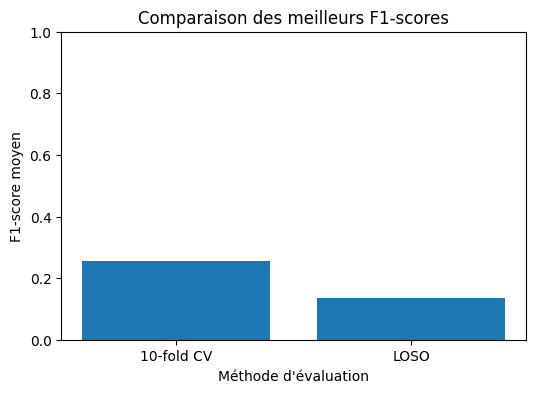

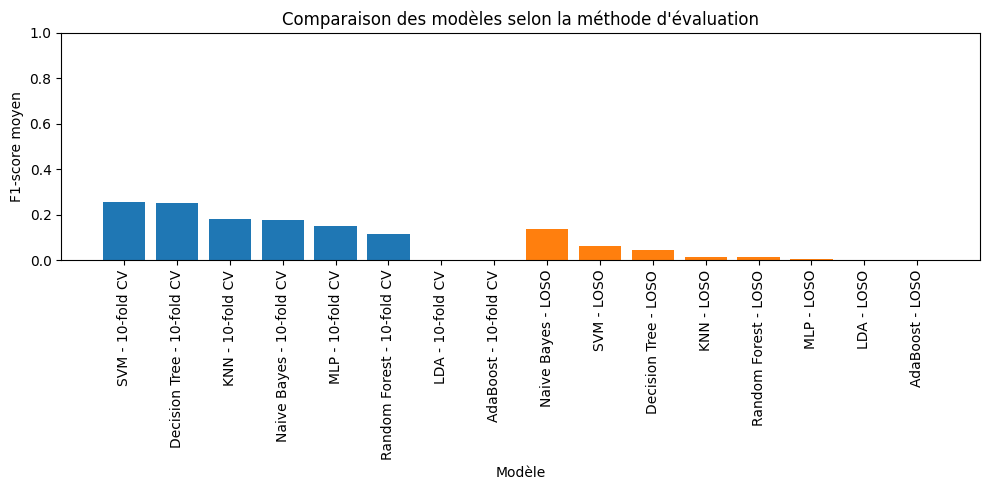

In [ ]:


import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score




models = {
    "LDA": LinearDiscriminantAnalysis(),

    "SVM": SVC(
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=50,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=300,
        random_state=42
    )
}




print("Début de l'évaluation 10-fold...\n")

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results_10fold = []

for i, (model_name, model) in enumerate(models.items(), start=1):

    print(f"[10-fold] Modèle {i}/{len(models)} : {model_name}")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    results_10fold.append({
        "Modèle": model_name,
        "Méthode": "10-fold CV",
        "F1-score moyen": scores.mean(),
        "Écart-type": scores.std()
    })

    print(f"   F1 moyen = {scores.mean():.4f}")
    print("   Terminé.\n")


results_10fold_df = pd.DataFrame(results_10fold)

print("Évaluation 10-fold terminée.")
print("====================================\n")




print("Début de l'évaluation LOSO...\n")

groups = df["Participant"]
logo = LeaveOneGroupOut()

subjects = groups.unique()
n_subjects = len(subjects)

results_loso = []

for i, (model_name, model) in enumerate(models.items(), start=1):

    print(f"[LOSO] Modèle {i}/{len(models)} : {model_name}")

    f1_scores = []
    acc_scores = []
    precision_scores = []
    recall_scores = []

    fold_number = 1

    for train_idx, test_idx in logo.split(X, y, groups):

        subject_test = groups.iloc[test_idx].iloc[0]

        print(
            f"   Sujet {fold_number}/{n_subjects} testé : {subject_test}",
            end=" "
        )

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        acc_scores.append(acc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        print(f"| F1 = {f1:.4f}")

        fold_number += 1

    results_loso.append({
        "Modèle": model_name,
        "Méthode": "LOSO",
        "Accuracy moyenne": np.mean(acc_scores),
        "Precision moyenne": np.mean(precision_scores),
        "Recall moyen": np.mean(recall_scores),
        "F1-score moyen": np.mean(f1_scores),
        "Écart-type": np.std(f1_scores)
    })

    print(f"   F1 LOSO moyen pour {model_name} = {np.mean(f1_scores):.4f}")
    print("   Terminé.\n")


results_loso_df = pd.DataFrame(results_loso)

print("Évaluation LOSO terminée.")
print("====================================\n")




comparison_df = pd.concat([
    results_10fold_df,
    results_loso_df
], ignore_index=True)

comparison_df = comparison_df.sort_values(
    by=["Méthode", "F1-score moyen"],
    ascending=[True, False]
)

print("Tableau comparatif final :")
display(comparison_df)




best_10fold = results_10fold_df.sort_values(
    by="F1-score moyen",
    ascending=False
).iloc[0]

best_loso = results_loso_df.sort_values(
    by="F1-score moyen",
    ascending=False
).iloc[0]

print("===== Meilleur modèle en 10-fold CV =====")
print("Modèle :", best_10fold["Modèle"])
print("F1-score moyen :", round(best_10fold["F1-score moyen"], 4))
print("Écart-type :", round(best_10fold["Écart-type"], 4))

print("\n===== Meilleur modèle en LOSO =====")
print("Modèle :", best_loso["Modèle"])
print("F1-score moyen :", round(best_loso["F1-score moyen"], 4))
print("Écart-type :", round(best_loso["Écart-type"], 4))
import matplotlib.pyplot as plt


best_scores = pd.DataFrame({
    "Méthode": ["10-fold CV", "LOSO"],
    "F1-score moyen": [
        best_10fold["F1-score moyen"],
        best_loso["F1-score moyen"]
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(best_scores["Méthode"], best_scores["F1-score moyen"])
plt.title("Comparaison des meilleurs F1-scores")
plt.xlabel("Méthode d'évaluation")
plt.ylabel("F1-score moyen")
plt.ylim(0, 1)
plt.show()


plt.figure(figsize=(10, 5))

for method in comparison_df["Méthode"].unique():
    subset = comparison_df[comparison_df["Méthode"] == method]
    plt.bar(
        subset["Modèle"] + " - " + method,
        subset["F1-score moyen"]
    )

plt.title("Comparaison des modèles selon la méthode d'évaluation")
plt.xlabel("Modèle")
plt.ylabel("F1-score moyen")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Interprétation et discussion

Répondez aux questions suivantes dans le notebook :

1. Quel modèle obtient le meilleur F1-score en 10-fold ?

Le modèle SVM obtient le meilleur F1-score en validation croisée 10-fold avec :

F1-score = 0.2551

Il est donc le modèle le plus performant dans cette évaluation.

2. Quel modèle obtient le meilleur F1-score en LOSO ?

Le modèle Naive Bayes obtient le meilleur F1-score en LOSO avec :

F1-score = 0.1350

C'est le modèle qui généralise le mieux aux sujets jamais vus parmi ceux testés.

3. Les performances chutent-elles en LOSO ? Pourquoi ?

Oui, les performances chutent fortement en LOSO.

Par exemple :
SVM :
10-fold = 0.2551
LOSO    = 0.0606

Cette baisse est normale car le modèle est testé sur un sujet totalement absent de l'ensemble d'apprentissage. Les signaux EEG présentent une forte variabilité inter-individuelle, ce qui rend la généralisation à un nouveau conducteur plus difficile.

4. Les classes sont-elles équilibrées ?

Non, les classes ne sont pas équilibrées.

La répartition observée est approximativement :

Classe 0 : 2283 échantillons

Classe 1 : 228 échantillons

soit environ :

91 % de classe 0

9 % de classe 1

Ce déséquilibre favorise les prédictions de la classe majoritaire et explique les faibles performances sur la classe 1.

5. Les résultats obtenus avec EEG seul vous semblent-ils suffisants pour une application réelle ?

Non.

Les meilleurs F1-scores obtenus restent faibles :

10-fold : 0.2551

LOSO    : 0.1350

Ces performances indiquent que les modèles détectent difficilement la charge cognitive élevée, notamment sur des sujets jamais vus. Une application réelle nécessiterait une meilleure robustesse et une meilleure capacité de généralisation.

6. Quelles limites voyez-vous à l'utilisation des labels subjectifs PAAS ?

Les scores PAAS sont basés sur l'auto-évaluation du participant et sont donc subjectifs.

Les principales limites sont :

perception différente de la difficulté selon les individus ;
influence de la fatigue, du stress ou de la motivation ;
erreurs de jugement du participant ;
incohérence possible entre la charge cognitive réelle et la note attribuée.

Ces labels peuvent donc contenir du bruit et limiter les performances des modèles.

7. Quelles améliorations proposeriez-vous ?

Plusieurs améliorations peuvent être envisagées :

- équilibrer les classes (SMOTE, sur-échantillonnage, sous-échantillonnage)

- collecter davantage de données et de participants

- sélectionner les caractéristiques EEG les plus pertinentes

- optimiser les hyperparamètres des modèles

- utiliser des modèles plus avancés (CNN, LSTM, Transformers)

### Analyse critique

Les résultats montrent que la détection de la charge cognitive est une tâche complexe. Les performances obtenues avec LOSO sont plus faibles que celles obtenues avec la validation croisée classique, ce qui indique que la généralisation à un nouveau conducteur reste difficile. L'utilisation des autres modalités (ECG, EDA et Gaze) pourrait améliorer les performances du système.

## 11. Mini-système d'adaptation

À partir de la prédiction du modèle, on peut simuler une décision d'adaptation.

Exemple :

| Prédiction | Décision |
|---|---|
| charge faible | interface normale |
| charge élevée | simplification de l'interface |
| charge élevée persistante | alerte conducteur |

## Question

Pourquoi faut-il être prudent avant de déclencher une alerte sur une seule prédiction ?

### Réponse

Il faut être prudent avant de déclencher une alerte sur une seule prédiction, car un modèle peut faire des erreurs ponctuelles. Une seule prédiction de charge élevée peut être due au bruit EEG, à un artefact, à un mauvais contact d'électrode ou à une erreur du modèle. Déclencher directement une alerte pourrait produire des faux positifs et perturber inutilement le conducteur.

Il est donc préférable d'attendre plusieurs prédictions consécutives de charge élevée avant de déclencher une alerte.

...

In [ ]:
def decision_system(predictions, persistence_threshold=3):


    decisions = []
    consecutive_high = 0

    for pred in predictions:

        if pred == 0:
            consecutive_high = 0
            decision = "interface normale"

        else:
            consecutive_high += 1

            if consecutive_high >= persistence_threshold:
                decision = "alerte conducteur"
            else:
                decision = "simplification de l'interface"

        decisions.append(decision)

    return decisions

predictions = [0, 0, 1, 1, 1, 0, 1, 1]

decisions = decision_system(predictions)

for p, d in zip(predictions, decisions):
    print(p, "->", d)

0 -> interface normale
0 -> interface normale
1 -> simplification de l'interface
1 -> simplification de l'interface
1 -> alerte conducteur
0 -> interface normale
1 -> simplification de l'interface
1 -> simplification de l'interface


## 12. Extension optionnelle — vers la multimodalité

Le cœur du TP est volontairement limité à l'EEG.

Une extension possible consiste à reproduire les mêmes étapes pour les autres modalités :

```text
ECG_Features_10s → Normalized_Features_10s/ECG → Normalized_Features_10s_With_Label/ECG
EDA_Features_10s → Normalized_Features_10s/EDA → Normalized_Features_10s_With_Label/EDA
Gaze_Features_10s → Normalized_Features_10s/Gaze → Normalized_Features_10s_With_Label/Gaze
```

Puis à fusionner les features :

```text
EEG + ECG
EEG + EDA
EEG + Gaze
EEG + ECG + EDA + Gaze
```

La fusion la plus simple est une concaténation des colonnes de features pour des fenêtres correspondant au même sujet, au même niveau et au même indice de fenêtre.

## Question

Pourquoi la multimodalité peut-elle améliorer la détection de la charge cognitive ?

### Réponse
L'EEG seul donne des performances limitées (F1 LOSO = 0.135). La multimodalité consiste à combiner plusieurs sources physiologiques complémentaires :

ECG : capture les variations de rythme cardiaque (fréquence cardiaque, variabilité HRV) liées au stress et à l'effort cognitif.
EDA (conductance électrodermale) : mesure l'activation du système nerveux autonome, indicateur d'arousal et de charge émotionnelle.
Gaze : le suivi du regard renseigne sur l'allocation de l'attention visuelle (fréquence de clignement, fixations, saccades).

Chacune de ces modalités capte un aspect différent de la charge cognitive. En les combinant, on réduit la dépendance à une seule source bruitée et on fournit au modèle une représentation plus complète et redondante de l'état du conducteur. Cela peut compenser les artefacts propres à chaque capteur et améliorer la robustesse en LOSO, où la généralisation inter-individuelle est l'enjeu principal.


...

On va procéder à des améliorations avant de passer à la multimodalité